# 03 - Experiment Design, Contact-Cap A/B Test

**Day 4, part 1, design.** Yesterday's descriptive work surfaced a clear pattern: **subscription falls monotonically as contact count rises, 13.0% at the 1st contact down to 5.5% at 6+.** That motivates a concrete operational question:

> **Hypothesis:** capping the campaign contact count at 3 (instead of unlimited) produces **equal-or-higher** subscription rates while consuming **fewer** call-centre resources.

This notebook specifies the experiment that *would* answer it cleanly. The dataset is **observational**, nobody was randomized to a cap, so this is the design we would run, and the yardstick against which the Day-4 part-2 quasi-experiment (`04_quasi_experiment.ipynb`) must be judged. It is a design spec, not a result.

In [1]:
# Day 4 setup: BigQuery (service account), figures, and statistics helpers.
# Every number is queried live from the marts, never a local CSV.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.cloud import bigquery
from google.oauth2 import service_account

sns.set_theme(style="whitegrid", context="talk")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
KEYFILE = REPO / "credentials" / "service-account.json"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PROJECT = json.loads(KEYFILE.read_text())["project_id"]
CREDS = service_account.Credentials.from_service_account_file(str(KEYFILE))
client = bigquery.Client(project=PROJECT, credentials=CREDS, location="US")
MARTS = f"{PROJECT}.marts"


def save(fig, name):
    """Write a figure to reports/figures/ at print resolution."""
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved -> {path.relative_to(REPO)}")


def wilson_ci(k, n, conf=0.95):
    """Wilson score interval for a binomial proportion (better than normal
    approx at the tails). k successes out of n.
        centre = (p + z^2/2n) / (1 + z^2/n)
        half   = z/(1+z^2/n) * sqrt( p(1-p)/n + z^2/4n^2 )
    """
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return centre - half, centre + half


def two_prop_ztest(k1, n1, k2, n2):
    """Pooled two-proportion z-test (scipy supplies the normal CDF only).
        p_pool = (k1+k2)/(n1+n2)
        SE     = sqrt( p_pool(1-p_pool)(1/n1 + 1/n2) )
        z      = (p1 - p2) / SE
    Returns (p1, p2, z, two_sided_p).
    """
    p1, p2 = k1 / n1, k2 / n2
    p_pool = (k1 + k2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return p1, p2, z, p_value


def pct(v, _=None):
    return f"{v:.0%}"


print(f"project={PROJECT}  connected.")


project=bank-campaign-causal  connected.


## 1. Formal hypothesis

| Element | Specification |
| --- | --- |
| **Unit of randomization** | the **client** (one person), not the call |
| **Arms** | A = uncapped (status quo); B = hard cap at 3 contacts/client |
| **Primary metric** | term-deposit **subscription rate** (binary per client) |
| **Design** | two-sided superiority test for powering; **business decision is non-inferiority on subscriptions + superiority on cost** |
| **MDE** | **1.0 percentage point absolute** (~9% relative on an 11.3% base) |
| **alpha / power** | 0.05 (two-sided) / 0.80 |

**Null vs alternative (primary):**

- $H_0:\ p_B = p_A$, capping does not change the subscription rate.
- $H_1:\ p_B \neq p_A$, capping changes it (we power to detect a 1pp move).

**Secondary metrics:** contacts per subscription (efficiency), total contacts consumed (cost), high-value-segment conversion.

The business framing is a **non-inferiority + cost** decision: ship the cap if subscriptions are *no worse* than uncapped within a 1pp margin **and** it spends materially fewer calls. We power the simpler two-sided test below because its sample size is the conservative (larger) requirement.

### Baseline rate and standard deviation

In [2]:
# Baseline subscription rate and its standard deviation, from the warehouse.
base = client.query(f"""
    select count(*) as n,
           countif(subscribed) as subscribers,
           avg(cast(subscribed as int64)) as rate,
           stddev(cast(subscribed as int64)) as sd
    from `{MARTS}.mart_campaign_outcomes`
""").to_dataframe().iloc[0]

P0 = float(base["rate"])
SD = float(base["sd"])
print(f"baseline subscription rate p0 = {P0:.4f}  ({P0:.1%})")
print(f"std dev of the Bernoulli outcome = {SD:.4f}   (== sqrt(p0(1-p0)) = {np.sqrt(P0*(1-P0)):.4f})")
print(f"dataset size N = {int(base['n']):,}  ({int(base['subscribers']):,} subscribers)")

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


baseline subscription rate p0 = 0.1127  (11.3%)
std dev of the Bernoulli outcome = 0.3162   (== sqrt(p0(1-p0)) = 0.3162)
dataset size N = 41,188  (4,640 subscribers)


## 2. Required sample size (two-proportion z-test, by hand)

For two equally-sized arms, detecting a difference between baseline $p_1$ and treatment $p_2 = p_1 + \text{MDE}$:

$$ n_{\text{per arm}} = \frac{\left(z_{1-\alpha/2}\sqrt{2\bar p(1-\bar p)} + z_{1-\beta}\sqrt{p_1(1-p_1)+p_2(1-p_2)}\right)^2}{(p_2-p_1)^2}, \quad \bar p = \tfrac{p_1+p_2}{2} $$

We compute every term explicitly rather than calling a black-box power function, a reviewer can audit each piece.

In [3]:
alpha, power, mde = 0.05, 0.80, 0.01
p1 = P0
p2 = P0 + mde
p_bar = (p1 + p2) / 2

z_alpha = stats.norm.ppf(1 - alpha / 2)   # 1.95996 for alpha=0.05 two-sided
z_beta = stats.norm.ppf(power)            # 0.84162 for 80% power

numerator = (z_alpha * np.sqrt(2 * p_bar * (1 - p_bar))
             + z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
n_per_arm = numerator / (p2 - p1) ** 2

print(f"z_(1-alpha/2) = {z_alpha:.5f}")
print(f"z_(1-beta)    = {z_beta:.5f}")
print(f"p1 = {p1:.4f}, p2 = {p2:.4f}, p_bar = {p_bar:.4f}")
print("-" * 48)
print(f"n per arm = {n_per_arm:,.1f}  ->  {np.ceil(n_per_arm):,.0f}")
print(f"total N required (2 arms) = {2*np.ceil(n_per_arm):,.0f}")

z_(1-alpha/2) = 1.95996
z_(1-beta)    = 0.84162
p1 = 0.1127, p2 = 0.1227, p_bar = 0.1177
------------------------------------------------
n per arm = 16,294.9  ->  16,295
total N required (2 arms) = 32,590


### How does this compare to the dataset we actually hold?

The dataset has 41,188 clients. Split 50/50 that is **20,594 per arm**, *more* than the 16,301/arm a 1pp test needs. So the data is large enough to detect **smaller** effects than 1pp. The chart below inverts the formula: required sample size vs MDE, with the dataset's per-arm capacity drawn in.

dataset per-arm capacity (50/50 split) = 20,594
smallest MDE detectable with that capacity ~ 0.90 pp
required n/arm at MDE=1.0pp = 16,295


saved -> reports\figures\experiment_sample_size_vs_mde.png


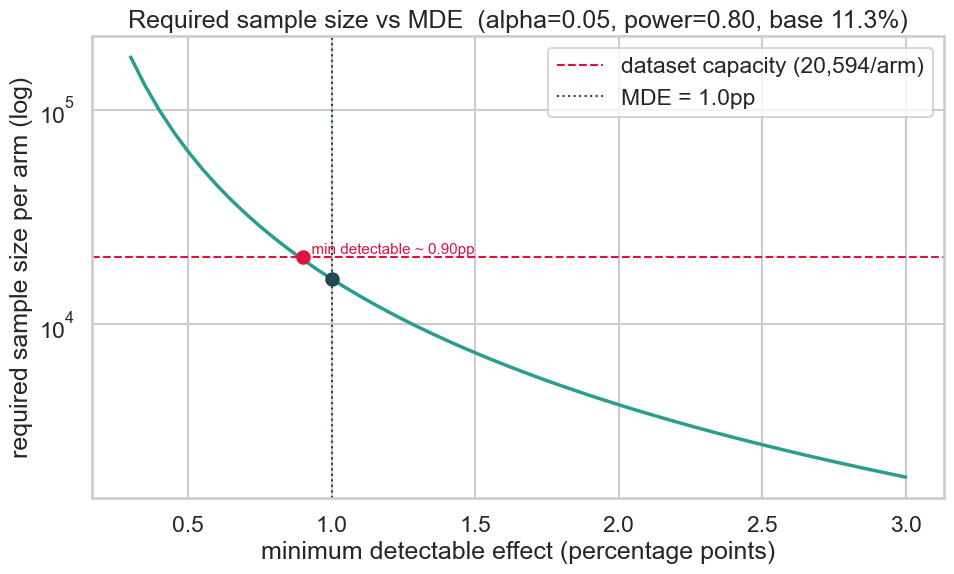

In [4]:
# Required n-per-arm across a range of MDEs, and the smallest MDE the dataset
# (20,594 per arm at a 50/50 split) can detect at alpha=0.05, power=0.80.
def n_required(mde, p1=P0, alpha=0.05, power=0.80):
    p2 = p1 + mde
    pb = (p1 + p2) / 2
    za, zb = stats.norm.ppf(1 - alpha / 2), stats.norm.ppf(power)
    return ((za * np.sqrt(2 * pb * (1 - pb))
             + zb * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2) / (mde ** 2)

mdes = np.arange(0.003, 0.0305, 0.0005)
ns = np.array([n_required(m) for m in mdes])
CAPACITY = 41188 / 2  # per arm at 50/50

detectable = mdes[ns <= CAPACITY].min()
print(f"dataset per-arm capacity (50/50 split) = {CAPACITY:,.0f}")
print(f"smallest MDE detectable with that capacity ~ {detectable*100:.2f} pp")
print(f"required n/arm at MDE=1.0pp = {n_required(0.01):,.0f}")

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(mdes * 100, ns, color="#2a9d8f", linewidth=2.5)
ax.axhline(CAPACITY, color="crimson", linestyle="--", linewidth=1.5,
           label=f"dataset capacity ({CAPACITY:,.0f}/arm)")
ax.axvline(1.0, color="#264653", linestyle=":", linewidth=1.5, label="MDE = 1.0pp")
ax.scatter([1.0], [n_required(0.01)], color="#264653", zorder=5, s=80)
ax.scatter([detectable * 100], [CAPACITY], color="crimson", zorder=5, s=80)
ax.annotate(f"  min detectable ~ {detectable*100:.2f}pp",
            (detectable * 100, CAPACITY), fontsize=11, color="crimson", va="bottom")
ax.set_yscale("log")
ax.set_xlabel("minimum detectable effect (percentage points)")
ax.set_ylabel("required sample size per arm (log)")
ax.set_title("Required sample size vs MDE  (alpha=0.05, power=0.80, base 11.3%)")
ax.legend()
save(fig, "experiment_sample_size_vs_mde.png")
plt.show()

## 3. Randomization unit, client, not call

Randomize at the **client** level: each client is assigned once to an arm and every call to that client obeys the arm's policy.

**Why not the call?** The cap is fundamentally a *per-client* rule, "stop after this person's 3rd contact." Randomizing individual calls would let the same client land in both arms, which:

- **breaks the treatment definition** (you cannot cap a client at 3 if their 4th call was independently assigned to the uncapped arm);
- **violates SUTVA / independence**, calls to one client are correlated (same person, same propensity), so call-level units are pseudo-replicated and would overstate power;
- **contaminates** the cost metric, since contacts-per-client is the very quantity the policy changes.

Client-level assignment keeps the unit of analysis equal to the unit of intervention and the unit the metric is defined on.

## 4. Guardrail metrics (declared *before* any analysis)

Pre-registering guardrails stops us cherry-picking a flattering cut after seeing the data. The cap must not win on the headline while quietly harming these:

1. **Cost per subscription**, proxy: **contacts per subscription** (total contacts / subscribers). The cap should *lower* this; a guardrail breach is it rising.
2. **High-value-segment conversion**, subscription rate among **retired, management, student** clients must not drop under the cap (these segments convert well and are worth the calls).
3. **Weak-segment over-contact**, **blue-collar** clients (lowest conversion, 6.9%) must not be *over*-contacted; their average contacts should fall, not rise, under a cap.

Each is checked across the observational groups in notebook 04.

## 5. Threats to validity

- **Novelty effect, N/A here.** Novelty bias afflicts live tests where users react to a *change*; this is a retrospective observational analysis, so there is no novelty to wear off.
- **Primacy / change-aversion, low risk.** Call-centre agents, not customers, would adapt to a cap; with scripted contact rules the learning curve is short. Flag it for a live rollout, not for this analysis.
- **Selection effects, THE live threat.** In the observational data, clients who reached contact #6 are **systematically different** from those who stopped at #2: persistence in the data reflects who was hard to reach or hard to convince, and who had *not yet said yes*. Comparing many-contact vs few-contact clients therefore confounds the contact cap with client engagement. Notebook 04 measures this imbalance head-on; Day 5 adjusts for it.

---
**Design complete.** A clean test needs ~16.3k clients per arm (< the data we hold), randomized at the client level, with three pre-declared guardrails. We have **no such randomized data**, so `04_quasi_experiment.ipynb` builds the closest observational proxy, and stress-tests why its headline number cannot be trusted as causal.